# From EOS fit to prediction uncertainty

A fitted parameter table is not the end of an EOS analysis. This notebook
fits a BM3 model to reproducible synthetic P–V observations, carries the full
parameter covariance into a predicted pressure curve, and compares linear,
Monte Carlo, and independent-parameter treatments.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from peritheos import EOSUncertainty
from peritheos.eos.rt import BM3
from peritheos.fitting import fit_rt_eos

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(91)

truth = BM3(V0=10.0, K0=150.0, K0_prime=4.5)
volumes = np.linspace(8.5, 10.0, 24)
pressure_sigma = np.full(volumes.shape, 0.08)
pressures = truth.pressure(volumes) + rng.normal(0.0, pressure_sigma)

fit = fit_rt_eos(
    BM3,
    volume=volumes,
    pressure=pressures,
    initial={"V0": 9.95, "K0": 145.0, "K0_prime": 4.0},
    bounds={
        "V0": (9.5, 10.5),
        "K0": (50.0, 300.0),
        "K0_prime": (1.0, 10.0),
    },
    pressure_sigma=pressure_sigma,
    absolute_sigma=True,
)

print(fit.summary())

FitResult (BM3)
Success: True (status 2)
Message: `ftol` termination condition is satisfied.

Parameters:
  Name                Value      Std. error  Status
  V0                10.0044      0.00283222  free
  K0                149.008           1.197  free
  K0_prime          4.53031       0.0839167  free

Diagnostics:
  chi-square: 10.3427
  reduced chi-square: 0.492512
  degrees of freedom: 21
  AIC: -14.2024
  BIC: -10.6683

Solver:
  loss: linear
  f_scale: 1
  function evaluations: 5
  cost: 5.17137
  optimality: 5.53113e-06


## Inspect covariance, not only standard errors

The off-diagonal correlation coefficients are large. Treating the three
reported standard errors as independent would discard information learned by
the fit.

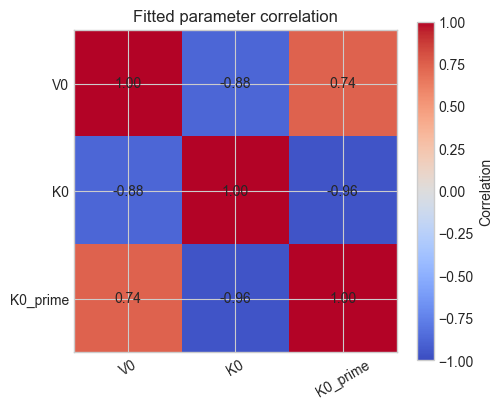

In [2]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
image = ax.imshow(fit.correlation, vmin=-1.0, vmax=1.0, cmap="coolwarm")
ax.set_xticks(range(len(fit.free_parameters)), fit.free_parameters, rotation=30)
ax.set_yticks(range(len(fit.free_parameters)), fit.free_parameters)
for row in range(len(fit.free_parameters)):
    for column in range(len(fit.free_parameters)):
        ax.text(
            column,
            row,
            f"{fit.correlation[row, column]:.2f}",
            ha="center",
            va="center",
        )
fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Fitted parameter correlation")
plt.show()

## Propagate the complete fit covariance

`FitResult.eos_uncertainty()` preserves the parameter ordering and covariance
automatically. The shaded interval is pointwise, not a simultaneous confidence
band for the entire curve. The region left of the dashed line is extrapolation.

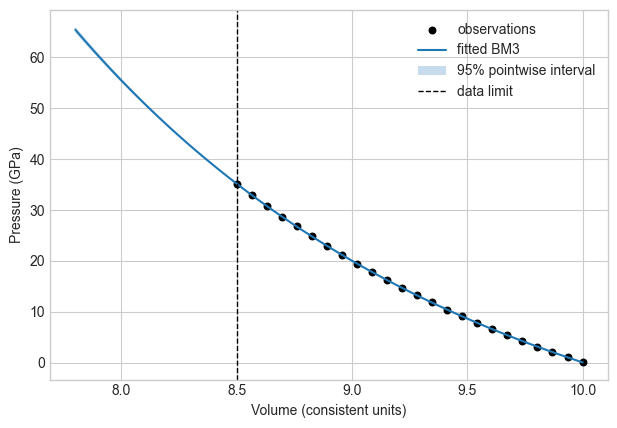

In [3]:
uncertainty = fit.eos_uncertainty()
prediction_volumes = np.linspace(7.8, 10.0, 100)
linear = uncertainty.pressure(
    prediction_volumes,
    method="linear",
    full_covariance=True,
    confidence=0.95,
)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.scatter(volumes, pressures, s=22, color="black", label="observations")
ax.plot(prediction_volumes, linear.value, label="fitted BM3")
ax.fill_between(
    prediction_volumes,
    linear.lower,
    linear.upper,
    alpha=0.25,
    label="95% pointwise interval",
)
ax.axvline(volumes.min(), color="black", ls="--", lw=1, label="data limit")
ax.set(xlabel="Volume (consistent units)", ylabel="Pressure (GPa)")
ax.legend()
plt.show()

## Predicted curve points are correlated

The same uncertain EOS parameters affect every point on the curve. Requesting
`full_covariance=True` exposes that shared uncertainty; it should not be
confused with independent scatter around each predicted pressure.

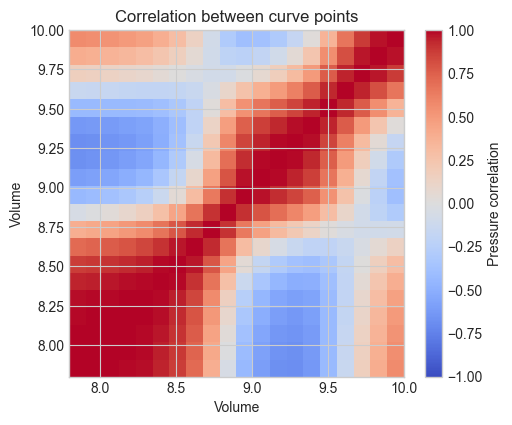

In [4]:
selected = np.linspace(0, prediction_volumes.size - 1, 20, dtype=int)
curve_covariance = linear.covariance[np.ix_(selected, selected)]
curve_sigma = np.sqrt(np.diag(curve_covariance))
curve_correlation = curve_covariance / np.outer(curve_sigma, curve_sigma)

fig, ax = plt.subplots(figsize=(5.4, 4.5))
image = ax.imshow(
    curve_correlation,
    origin="lower",
    extent=(prediction_volumes.min(), prediction_volumes.max()) * 2,
    vmin=-1.0,
    vmax=1.0,
    cmap="coolwarm",
    aspect="auto",
)
fig.colorbar(image, ax=ax, label="Pressure correlation")
ax.set(xlabel="Volume", ylabel="Volume", title="Correlation between curve points")
plt.show()

## Compare statistical assumptions and propagation methods

The independent approximation below deliberately drops fit correlations. The
small Monte Carlo sample keeps the executable documentation fast; increase
`sample_count` to at least 10,000 for a reported analysis.

In [5]:
independent = EOSUncertainty(
    fit.model,
    parameter_errors=fit.standard_errors,
).pressure(prediction_volumes)

monte_carlo = uncertainty.pressure(
    prediction_volumes,
    method="monte_carlo",
    sample_count=300,
    random_state=42,
)

probe_indices = [0, 50, 99]
print(" volume   correlated SE   independent SE   Monte Carlo interval")
for index in probe_indices:
    print(
        f" {prediction_volumes[index]:6.3f} "
        f"{linear.standard_error[index]:15.4f} "
        f"{independent.standard_error[index]:16.4f} "
        f"[{monte_carlo.lower[index]:8.3f}, {monte_carlo.upper[index]:8.3f}]"
    )
print(f"Rejected Monte Carlo fraction: {monte_carlo.rejected_fraction:.3f}")

 volume   correlated SE   independent SE   Monte Carlo interval
  7.800          0.2872           0.8785 [  64.855,   65.965]
  8.911          0.0231           0.2221 [  22.387,   22.475]
 10.000          0.0418           0.0423 [  -0.025,    0.151]
Rejected Monte Carlo fraction: 0.000


## Takeaways

1. Use `fit.eos_uncertainty()` to preserve fitted covariance automatically.
2. Parameter correlation can substantially narrow or widen prediction errors.
3. Different curve points are correlated because they share EOS parameters.
4. Linear intervals are local approximations; Monte Carlo can reveal
   asymmetric intervals and invalid parameter draws.